In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/demand-forecasting-kernels-only/sample_submission.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/train.csv
/kaggle/input/competitions/demand-forecasting-kernels-only/test.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv(
    "/kaggle/input/competitions/demand-forecasting-kernels-only/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/demand-forecasting-kernels-only/test.csv"
)

In [4]:
train.shape

(913000, 4)

In [5]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [8]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [9]:
train["store"].nunique()

10

In [10]:
train["item"].nunique()

50

In [11]:
train["date"].min(), train["date"].max()

('2013-01-01', '2017-12-31')

In [12]:
train["date"] = pd.to_datetime(train["date"])

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


**visualize one time series:**

In [15]:
sample = train[
    (train["store"] == 1) &
    (train["item"] == 1)
]

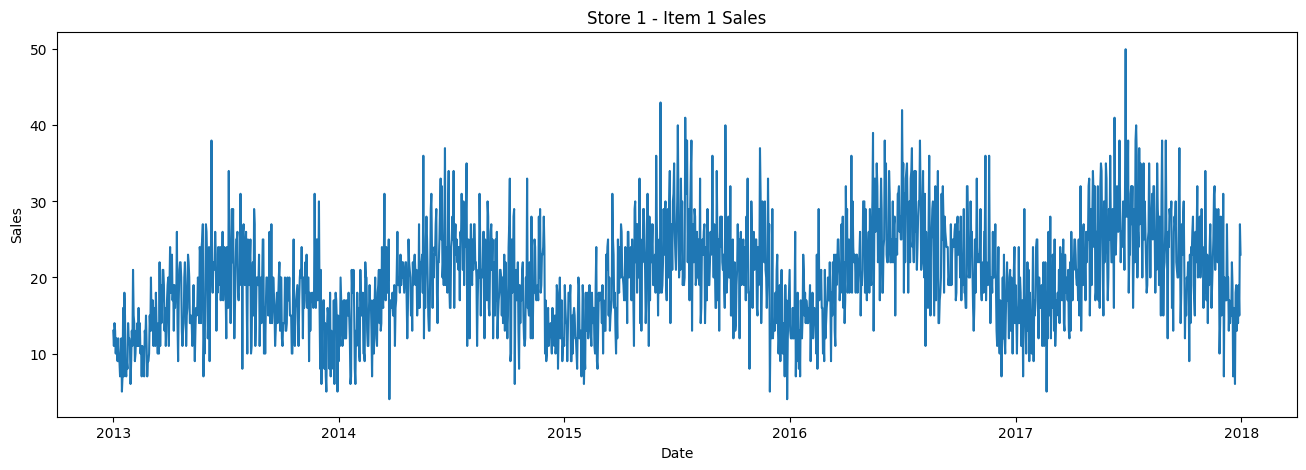

In [16]:
plt.figure(figsize=(16,5))

plt.plot(sample["date"], sample["sales"])

plt.title("Store 1 - Item 1 Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [18]:
# Make sure date is datetime
train["date"] = pd.to_datetime(train["date"])

# Year
train["year"] = train["date"].dt.year

# Month
train["month"] = train["date"].dt.month

# Day of month
train["day"] = train["date"].dt.day

# Day of week
# Monday = 0, Sunday = 6
train["day_of_week"] = train["date"].dt.dayofweek

# Week of year
train["week_of_year"] = train["date"].dt.isocalendar().week.astype(int)

# Quarter
train["quarter"] = train["date"].dt.quarter

# Is weekend?
train["is_weekend"] = (
    train["day_of_week"] >= 5
).astype(int)

In [19]:
train.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1


In [20]:
# Yesterday's sales
train["lag_1"] = (
    train.groupby(["store", "item"])["sales"]
         .shift(1)
)

# Sales one week ago
train["lag_7"] = (
    train.groupby(["store", "item"])["sales"]
         .shift(7)
)

# Sales one month ago
train["lag_30"] = (
    train.groupby(["store", "item"])["sales"]
         .shift(30)
)

In [21]:
train[
    ["date", "store", "item", "sales", "lag_1", "lag_7", "lag_30"]
].head(35)

,date,store,item,sales,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,NaN,NaN,NaN
1,2013-01-02,1,1,11,13.0,NaN,NaN
2,2013-01-03,1,1,14,11.0,NaN,NaN
3,2013-01-04,1,1,13,14.0,NaN,NaN
4,2013-01-05,1,1,10,13.0,NaN,NaN
5,2013-01-06,1,1,12,10.0,NaN,NaN
6,2013-01-07,1,1,10,12.0,NaN,NaN
7,2013-01-08,1,1,9,10.0,13.0,NaN
8,2013-01-09,1,1,12,9.0,11.0,NaN
9,2013-01-10,1,1,9,12.0,14.0,NaN


In [22]:
# 7-day rolling average
train["rolling_mean_7"] = (
    train.groupby(["store", "item"])["sales"]
         .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

# 30-day rolling average
train["rolling_mean_30"] = (
    train.groupby(["store", "item"])["sales"]
         .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

In [23]:
train[
    [
        "date",
        "sales",
        "rolling_mean_7",
        "rolling_mean_30"
    ]
].head(40)

,date,sales,rolling_mean_7,rolling_mean_30
0,2013-01-01,13,NaN,NaN
1,2013-01-02,11,NaN,NaN
2,2013-01-03,14,NaN,NaN
3,2013-01-04,13,NaN,NaN
4,2013-01-05,10,NaN,NaN
5,2013-01-06,12,NaN,NaN
6,2013-01-07,10,NaN,NaN
7,2013-01-08,9,11.857143,NaN
8,2013-01-09,12,11.285714,NaN
9,2013-01-10,9,11.428571,NaN


In [24]:
train = train.dropna().reset_index(drop=True)

In [25]:
train.isnull().sum()

date               0
store              0
item               0
sales              0
year               0
month              0
day                0
day_of_week        0
week_of_year       0
quarter            0
is_weekend         0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64

In [26]:
feature_columns = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30"
]

X = train[feature_columns]
y = train["sales"]

In [27]:
print(X.shape)
print(y.shape)

(898000, 14)
(898000,)


In [29]:
train_data = train[train["year"] < 2017]

valid_data = train[train["year"] == 2017]

In [31]:
X_train = train_data[feature_columns]
y_train = train_data["sales"]

X_valid = valid_data[feature_columns]
y_valid = valid_data["sales"]

In [32]:
print(X_train.shape)
print(X_valid.shape)

print(y_train.shape)
print(y_valid.shape)

(715500, 14)
(182500, 14)
(715500,)
(182500,)


**Train Initial XGBoost Model:**

In [33]:
from xgboost import XGBRegressor

In [34]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [35]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
predictions = model.predict(X_valid)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [38]:
mae = mean_absolute_error(y_valid, predictions)
print("MAE:", mae)

MAE: 6.093850612640381


In [39]:
rmse = np.sqrt(mean_squared_error(y_valid, predictions))
print("RMSE:", rmse)

RMSE: 7.918973673587301


In [40]:
mape = np.mean(
    np.abs((y_valid - predictions) / (y_valid + 1e-8))
) * 100

print("MAPE:", mape)

MAPE: 12.570081972007907


In [41]:
bias = np.mean(predictions - y_valid)

print("Bias:", bias)

Bias: -0.030878034617802867


In [42]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
12,rolling_mean_7,0.448557
10,lag_7,0.279610
13,rolling_mean_30,0.093068
8,is_weekend,0.089500
5,day_of_week,0.055396
9,lag_1,0.014159
3,month,0.007158
6,week_of_year,0.004653
4,day,0.003421
7,quarter,0.001407


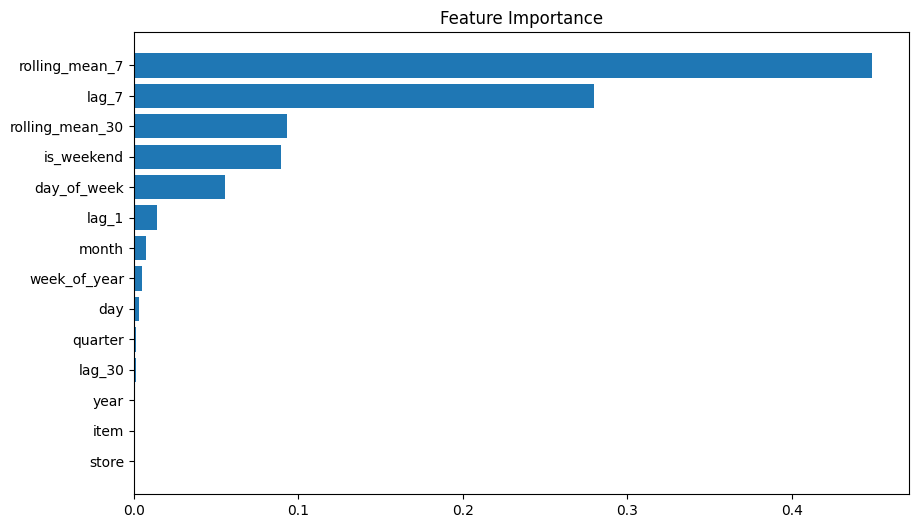

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

**Rolling-Origin Backtesting:**

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from xgboost import XGBRegressor

def evaluate_year(train_df, valid_df):

    X_train = train_df[feature_columns]
    y_train = train_df["sales"]

    X_valid = valid_df[feature_columns]
    y_valid = valid_df["sales"]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)

    mae = mean_absolute_error(y_valid, predictions)

    rmse = np.sqrt(mean_squared_error(y_valid, predictions))

    mape = np.mean(
        np.abs((y_valid - predictions) / (y_valid + 1e-8))
    ) * 100

    bias = np.mean(predictions - y_valid)

    return mae, rmse, mape, bias

In [48]:
train_fold = train[train["year"] <= 2014]

valid_fold = train[train["year"] == 2015]

evaluate_year(train_fold, valid_fold)

(5.752185821533203,
 np.float64(7.480253801170896),
 np.float64(13.443059296150746),
 np.float64(0.005166331069110191))

In [49]:
fold1 = evaluate_year(train_fold, valid_fold)
print(fold1)

(5.752185821533203, np.float64(7.480253801170896), np.float64(13.443059296150746), np.float64(0.005166331069110191))


In [50]:
train_fold = train[train["year"] <= 2015]

valid_fold = train[train["year"] == 2016]

fold2 = evaluate_year(train_fold, valid_fold)

print(fold2)

(6.0012922286987305, np.float64(7.813499691898806), np.float64(12.812324920678067), np.float64(-0.20082192542904714))


In [51]:
train_fold = train[train["year"] <= 2016]

valid_fold = train[train["year"] == 2017]

fold3 = evaluate_year(train_fold, valid_fold)

print(fold3)

(6.093850612640381, np.float64(7.918973673587301), np.float64(12.570081972007907), np.float64(-0.030878034617802867))


In [52]:
import pandas as pd

results = pd.DataFrame({
    "Fold": [
        "2015",
        "2016",
        "2017"
    ],
    "MAE": [
        fold1[0],
        fold2[0],
        fold3[0]
    ],
    "RMSE": [
        fold1[1],
        fold2[1],
        fold3[1]
    ],
    "MAPE": [
        fold1[2],
        fold2[2],
        fold3[2]
    ],
    "Bias": [
        fold1[3],
        fold2[3],
        fold3[3]
    ]
})

results

,Fold,MAE,RMSE,MAPE,Bias
0,2015,5.752186,7.480254,13.443059,0.005166
1,2016,6.001292,7.813500,12.812325,-0.200822
2,2017,6.093851,7.918974,12.570082,-0.030878


In [53]:
results.mean(numeric_only=True)

MAE      5.949110
RMSE     7.737576
MAPE    12.941822
Bias    -0.075511
dtype: float64

In [54]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

metrics = {
    "MAE": 5.949,
    "RMSE": 7.738,
    "MAPE": 12.942,
    "Bias": -0.076
}

joblib.dump(metrics, "metrics.pkl")

['metrics.pkl']